In [2]:
import pandas as pd
data = pd.read_excel("https://confrecordings.ams3.digitaloceanspaces.com/countries.xlsx")

print(data.head())

  country   latitude  longitude                  name
0      AD  42.546245   1.601554               Andorra
1      AE  23.424076  53.847818  United Arab Emirates
2      AF  33.939110  67.709953           Afghanistan
3      AG  17.060816 -61.796428   Antigua and Barbuda
4      AI  18.220554 -63.068615              Anguilla


In [3]:
print(data.shape)

(245, 4)


In [4]:
print(data.isnull().sum())

country      1
latitude     1
longitude    1
name         0
dtype: int64


In [5]:
print(data.dropna(inplace=True))
print(data.isnull().sum())

None
country      0
latitude     0
longitude    0
name         0
dtype: int64


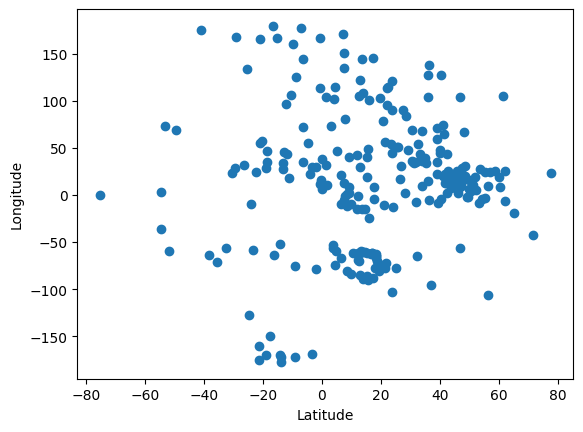

In [6]:
import matplotlib.pyplot as plt


plt.scatter(data['latitude'],data['longitude'])
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.show()

In [7]:
from sklearn.cluster import KMeans

xfeatures = data[['latitude','longitude']]
km = KMeans(n_clusters=7)
clusters = km.fit_predict(xfeatures)
data['cluster_continents'] = clusters
print(data.head())



  country   latitude  longitude                  name  cluster_continents
0      AD  42.546245   1.601554               Andorra                   6
1      AE  23.424076  53.847818  United Arab Emirates                   0
2      AF  33.939110  67.709953           Afghanistan                   0
3      AG  17.060816 -61.796428   Antigua and Barbuda                   4
4      AI  18.220554 -63.068615              Anguilla                   4


In [8]:
print(data[data['cluster_continents']==0])

print(data[data['cluster_continents']==1])

print(data[data['cluster_continents']==2])

print(data[data['cluster_continents']==3])

print(data[data['cluster_continents']==4])

print(data[data['cluster_continents']==5])

print(data[data['cluster_continents']==6])

    country   latitude  longitude                               name  \
1        AE  23.424076  53.847818               United Arab Emirates   
2        AF  33.939110  67.709953                        Afghanistan   
6        AM  40.069099  45.038189                            Armenia   
15       AZ  40.143105  47.576927                         Azerbaijan   
18       BD  23.684994  90.356331                         Bangladesh   
22       BH  25.930414  50.637772                            Bahrain   
30       BT  27.514162  90.433601                             Bhutan   
54       DJ  11.825138  42.590275                           Djibouti   
63       ER  15.179384  39.782334                            Eritrea   
65       ET   9.145000  40.489673                           Ethiopia   
93       HM -53.081810  73.504158  Heard Island and McDonald Islands   
102      IN  20.593684  78.962880                              India   
103      IO  -6.343194  71.876519     British Indian Ocean Terri

In [9]:
print(data.groupby('cluster_continents')['name'].count())

cluster_continents
0    39
1     9
2    36
3    41
4    44
5    10
6    64
Name: name, dtype: int64


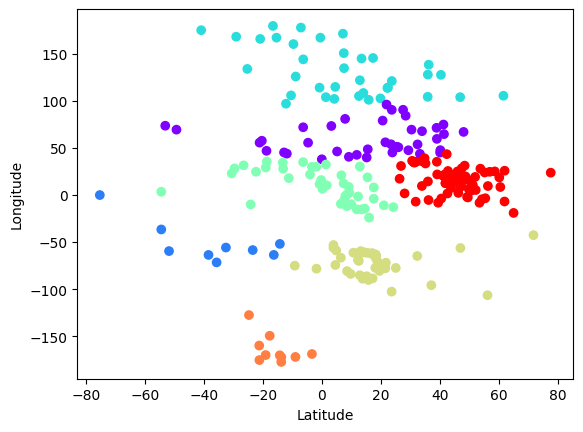

In [10]:
plt.scatter(data['latitude'],data['longitude'], c=data['cluster_continents'],cmap='rainbow')
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.show()

In [11]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=7)
clusters = hierarchical.fit_predict(xfeatures)
data['cluster_continents'] = clusters
print(data.head())

  country   latitude  longitude                  name  cluster_continents
0      AD  42.546245   1.601554               Andorra                   4
1      AE  23.424076  53.847818  United Arab Emirates                   2
2      AF  33.939110  67.709953           Afghanistan                   2
3      AG  17.060816 -61.796428   Antigua and Barbuda                   5
4      AI  18.220554 -63.068615              Anguilla                   5


In [12]:
print(data[data['cluster_continents']==0])

print(data[data['cluster_continents']==1])

print(data[data['cluster_continents']==2])

print(data[data['cluster_continents']==3])

print(data[data['cluster_continents']==4])

print(data[data['cluster_continents']==5])

print(data[data['cluster_continents']==6])

    country   latitude   longitude                      name  \
13       AU -25.274398  133.775136                 Australia   
26       BN   4.535277  114.727669                    Brunei   
36       CC -12.164165   96.870956   Cocos [Keeling] Islands   
45       CN  35.861660  104.195397                     China   
50       CX -10.447525  105.690449          Christmas Island   
67       FJ -16.578193  179.414413                      Fiji   
69       FM   7.425554  150.550812                Micronesia   
88       GU  13.444304  144.793731                      Guam   
92       HK  22.396428  114.109497                 Hong Kong   
98       ID  -0.789275  113.921327                 Indonesia   
111      JP  36.204824  138.252924                     Japan   
114      KH  12.565679  104.990963                  Cambodia   
118      KP  40.339852  127.510093               North Korea   
119      KR  35.907757  127.766922               South Korea   
123      LA  19.856270  102.495496      

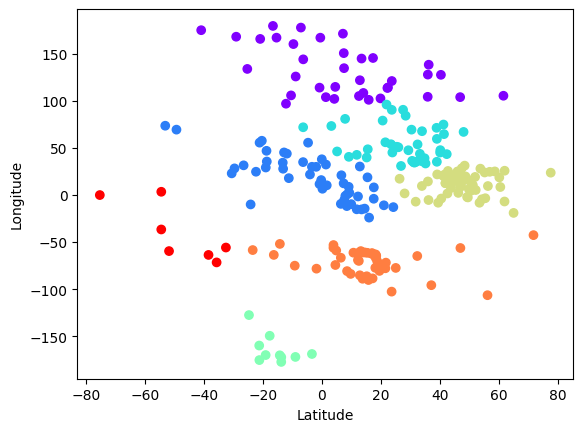

In [13]:
plt.scatter(data['latitude'],data['longitude'], c=data['cluster_continents'],cmap='rainbow')
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.show()

In [14]:
import geopandas as gpd
g01 = gpd.GeoDataFrame(data,geometry=gpd.points_from_xy(data['longitude'],data['latitude']))

print(g01)

    country   latitude  longitude                  name  cluster_continents  \
0        AD  42.546245   1.601554               Andorra                   4   
1        AE  23.424076  53.847818  United Arab Emirates                   2   
2        AF  33.939110  67.709953           Afghanistan                   2   
3        AG  17.060816 -61.796428   Antigua and Barbuda                   5   
4        AI  18.220554 -63.068615              Anguilla                   5   
..      ...        ...        ...                   ...                 ...   
240      YE  15.552727  48.516388                 Yemen                   2   
241      YT -12.827500  45.166244               Mayotte                   1   
242      ZA -30.559482  22.937506          South Africa                   1   
243      ZM -13.133897  27.849332                Zambia                   1   
244      ZW -19.015438  29.154857              Zimbabwe                   1   

                       geometry  
0      POINT (1.6

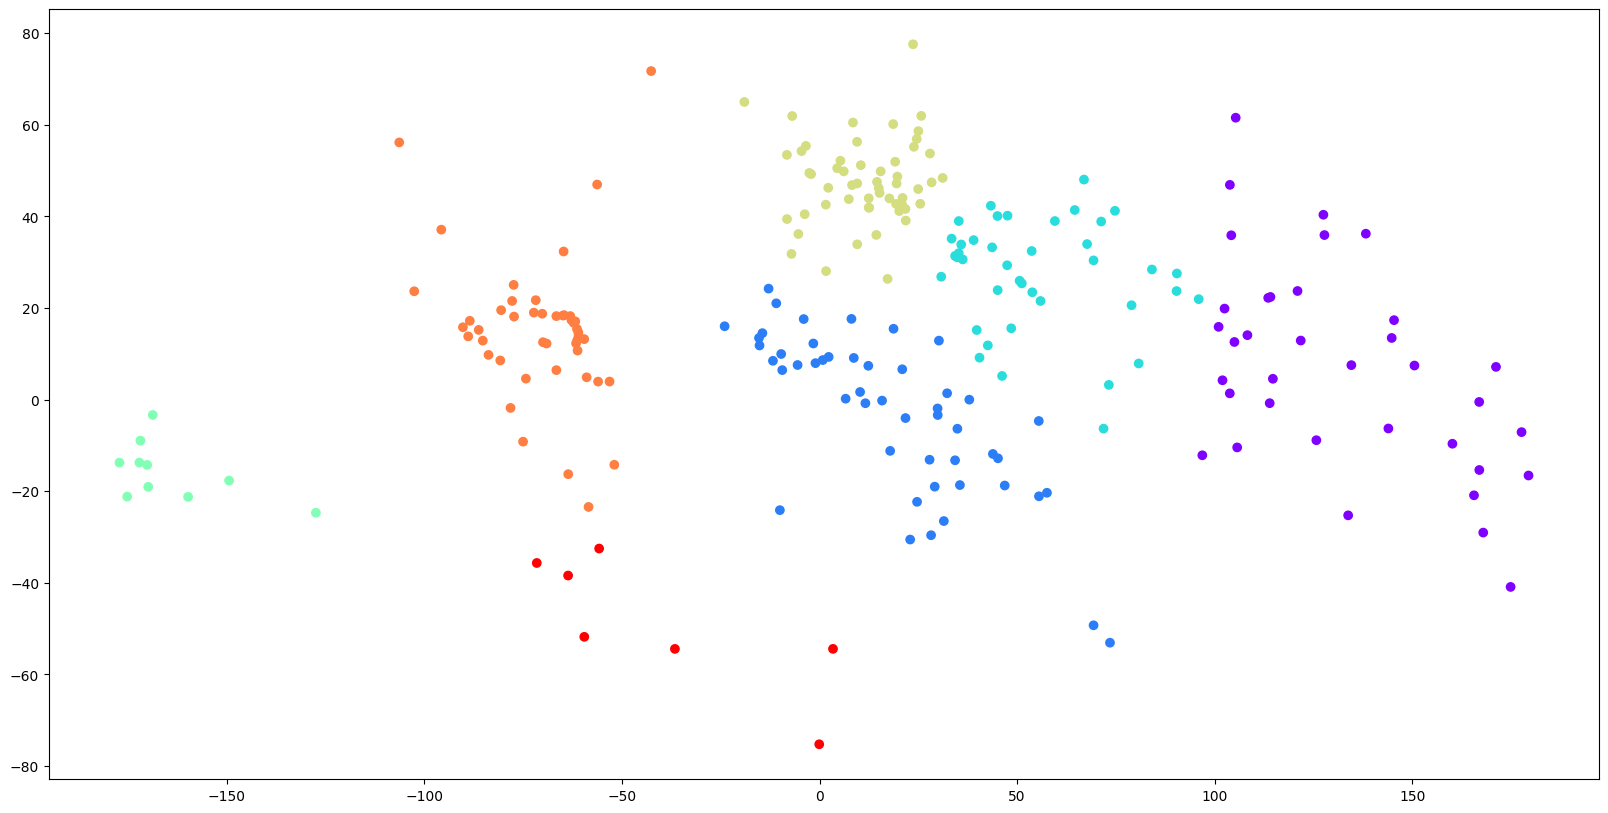

In [15]:
plt.figure(figsize=(20,10))

plt.scatter(data['longitude'],data['latitude'],c=data['cluster_continents'],cmap='rainbow')

plt.show()

In [16]:
import gradio as gr
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import geopandas as gpd


if 'data' not in globals() or data.empty:
    data = pd.read_excel("https://confrecordings.ams3.digitaloceanspaces.com/countries.xlsx")
    data.dropna(inplace=True)

if 'world' not in globals() or world.empty:
    world = gpd.read_file('zip:///content/ne_110m_admin_0_countries_lakes.zip')

def plot_clustered_world_map(n_clusters):
    # Extract features for clustering
    xfeatures = data[['longitude', 'latitude']]

    # Perform KMeans clustering
    # Added random_state for reproducibility and n_init to suppress a future warning
    km = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
    clusters = km.fit_predict(xfeatures)

    # Create a matplotlib figure and axes
    fig, ax = plt.subplots(figsize=(20, 10))

    # Plot the world map boundaries
    world.geometry.boundary.plot(ax=ax, color='gray', linewidth=0.5)

    # Plot the clustered country points
    ax.scatter(data['longitude'], data['latitude'], c=clusters, cmap='rainbow', s=50, alpha=0.7)

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'Country Clusters on World Map (KMeans, {n_clusters} clusters)')

    # Optional: adjust map extent if needed
    # ax.set_xlim([-180, 180])
    # ax.set_ylim([-90, 90])

    # Return the matplotlib figure for Gradio
    return fig

# Create Gradio Interface
iface_world_map = gr.Interface(
    fn=plot_clustered_world_map,
    inputs=gr.Slider(minimum=2, maximum=10, step=1, value=7, label="Number of Clusters"),
    outputs=gr.Plot(),
    title="Interactive Country Clustering on World Map",
    description="Adjust the number of clusters to visualize how countries group together on the world map using KMeans."
)

# Launch the interface inline in Colab
iface_world_map.launch(inline=True, share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://47156f930c98b5d537.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
